# Movie Success Prediction and Sentiment Study



---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# We need to download the VADER lexicon for sentiment analysis
nltk.download('vader_lexicon', quiet=True)

# Load the dataset
df = pd.read_csv('imdb_movie_data.csv')
print(f"Loaded {len(df)} movies. Here's a quick peek:")
display(df.head())

Loaded 2500 movies. Here's a quick peek:


,Movie_ID,Title,Genre,Budget_Millions,IMDB_Rating,User_Review,Box_Office_Millions
0,tt1000000,Movie Title 1,Romance,43.71,4.8,"It was okay, but could have been better. Absol...",49.21
1,tt1000001,Movie Title 2,Comedy,24.04,8.9,One of the best movies of the year. Great acti...,51.86
2,tt1000002,Movie Title 3,Romance,11.85,5.6,"Some good moments, but largely forgettable. Gr...",10.23
3,tt1000003,Movie Title 4,Action,86.68,6.9,"It was okay, but could have been better. Great...",36.05
4,tt1000004,Movie Title 5,Horror,24.44,7.7,Absolutely loved it! One of the best movies of...,19.13


## 1. Sentiment Analysis of User Reviews


In [ ]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(review):
    # Returns the compound score
    return sia.polarity_scores(str(review))['compound']

df['Sentiment_Compound'] = df['User_Review'].apply(get_sentiment)
print("Sentiment analysis complete! Let's look at the scores alongside the reviews:")
display(df[['Title', 'User_Review', 'Sentiment_Compound']].head())

Sentiment analysis complete! Let's look at the scores alongside the reviews:


,Title,User_Review,Sentiment_Compound
0,Movie Title 1,"It was okay, but could have been better. Absol...",0.9078
1,Movie Title 2,One of the best movies of the year. Great acti...,0.9201
2,Movie Title 3,"Some good moments, but largely forgettable. Gr...",0.9300
3,Movie Title 4,"It was okay, but could have been better. Great...",0.9528
4,Movie Title 5,Absolutely loved it! One of the best movies of...,0.8653


## 2. Genre-wise Sentiment Trends


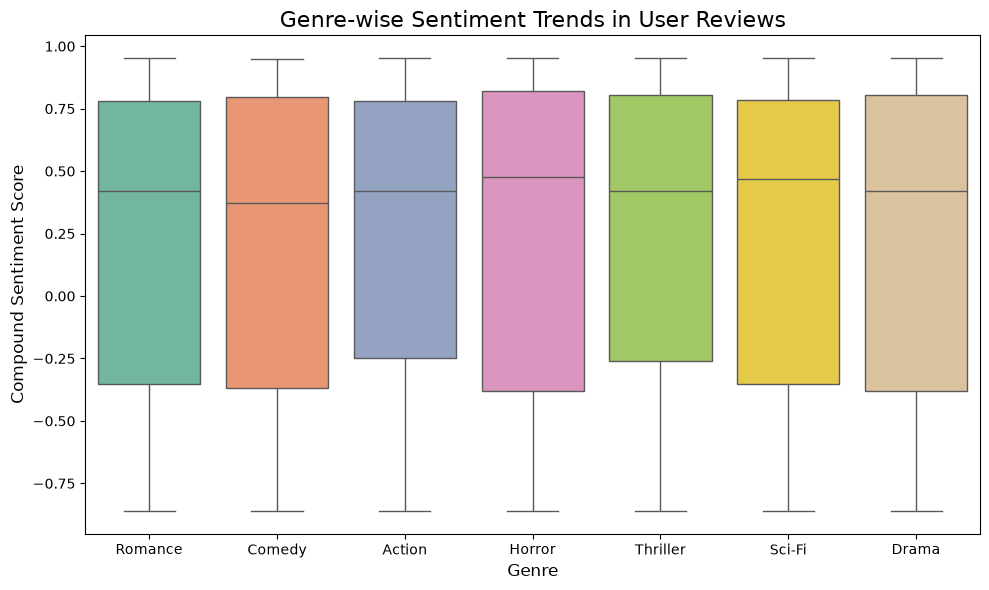


Exported genre-wise average sentiment to Genre_Sentiment.xlsx


,Genre,Average_Sentiment_Score
0,Action,0.278504
6,Thriller,0.277980
3,Horror,0.244761
2,Drama,0.230986
4,Romance,0.229060
5,Sci-Fi,0.221885
1,Comedy,0.216989


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Genre', y='Sentiment_Compound', data=df, palette='Set2')
plt.title('Genre-wise Sentiment Trends in User Reviews', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Compound Sentiment Score', fontsize=12)
plt.tight_layout()
plt.savefig('Genre_Sentiment_Trends.png') # Saving visual for delivery
plt.show()

# Calculate average sentiment per genre and export to Excel
genre_sentiment_avg = df.groupby('Genre')['Sentiment_Compound'].mean().reset_index()
genre_sentiment_avg.columns = ['Genre', 'Average_Sentiment_Score']
genre_sentiment_avg = genre_sentiment_avg.sort_values(by='Average_Sentiment_Score', ascending=False)

excel_path = 'Genre_Sentiment.xlsx'
genre_sentiment_avg.to_excel(excel_path, index=False)
print(f"\nExported genre-wise average sentiment to {excel_path}")
display(genre_sentiment_avg)

## 3. Predictive Modeling (Regression)


Model R-squared: 0.7515
Model RMSE: $45.91 Million


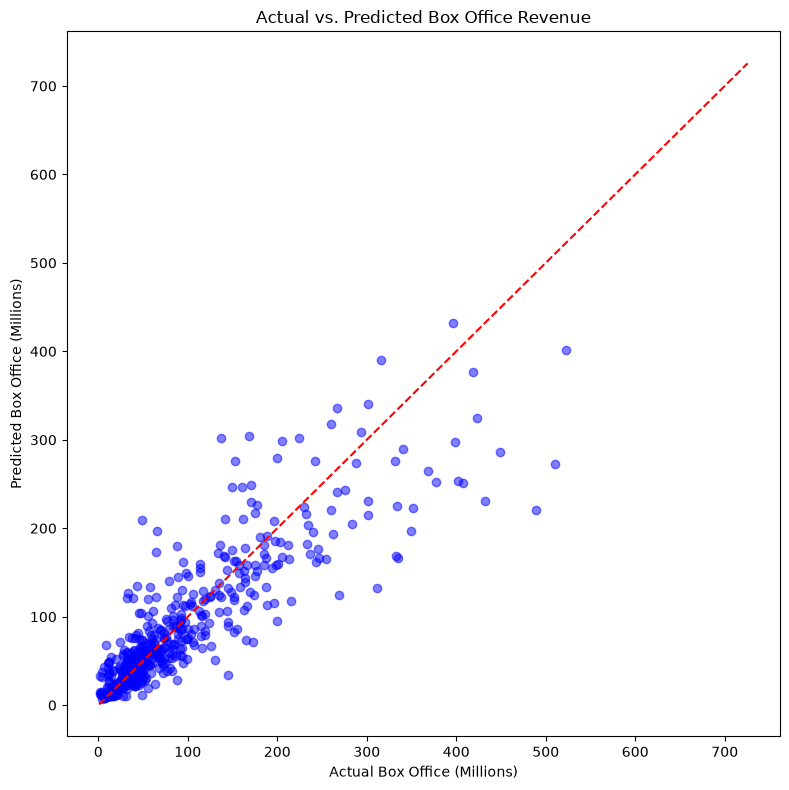

In [ ]:
# Select features (X) and target variable (y)
features = ['Budget_Millions', 'IMDB_Rating', 'Sentiment_Compound']
X = df[features]
y = df['Box_Office_Millions']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model R-squared: {r2:.4f}")
print(f"Model RMSE: ${rmse:.2f} Million")

# Visualize Actual vs Predicted Box Office
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Box Office (Millions)')
plt.ylabel('Predicted Box Office (Millions)')
plt.title('Actual vs. Predicted Box Office Revenue')
plt.tight_layout()
plt.savefig('Sentiment_Model_Results.png')
plt.show()

## 4. Feature Importance


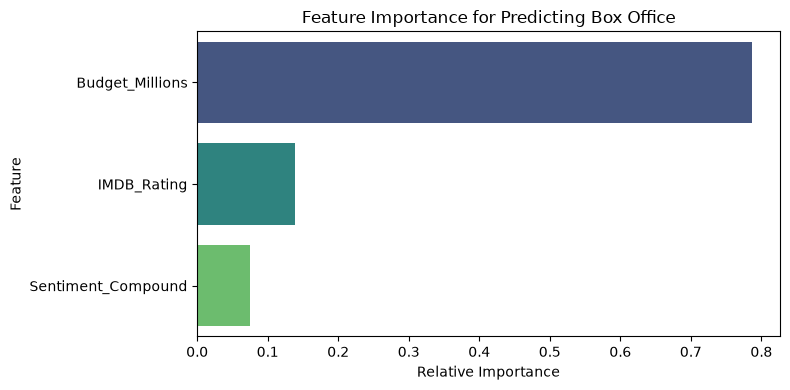

In [ ]:
importance = rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance for Predicting Box Office')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('Feature_Importance.png')
plt.show()